# 03 — H3 security / material audit (human review)

Functional classification: emotional security vs material/economic security vs status
display. Classify interaction **function**, not the object mentioned (a gown can be
status display, gift-as-care, or neither).

Saved Pass A/B/C + evidence packets only; rating cells stay blinded.
Special focus: leaf `1.6` (appearance) — Stage 10 found it on-label but the H3 question
is whether appearance content is doing *security* work.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh
from src.stage11_refined_construct_analysis.analysis import review_display as rd
from src.stage11_refined_construct_analysis.analysis.constructs import normalize_code

ctx = nh.setup("03_h3_security_material_audit")
cfg = ctx.cfg
HYP = "H3"
CODE_COL = "security_code"

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit


## 1. Overview — every H3 topic with labels

In [2]:
master = nh.load_master(cfg)
h3 = master[master[CODE_COL].notna()].copy()
h3["code_norm"] = h3[CODE_COL].map(normalize_code)
print(f"H3-coded topics: {len(h3)}")

overview = rd.annotation_overview(h3, CODE_COL, extra_cols=["secondary_id"])
display(overview[["topic", "taxonomy", "code", "code_norm", "mixed", "agree"]].head(60))
ctx.save_table(overview, "h3_topic_overview_labeled")
display(h3[CODE_COL].value_counts().head(20).to_frame("n"))
display(h3["code_norm"].value_counts(dropna=False).to_frame("n_norm"))

H3-coded topics: 80


,topic,taxonomy,code,code_norm,mixed,agree
0,18 — Ordering A Gown For Her,1.6 — Character Appearance & Self-Presentation,S13,S13,False,H3
1,77 — Haircut and Grooming Offered,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,H3
2,127 — Photographer Reviewing Pictures,1.6 — Character Appearance & Self-Presentation,S1,S1,False,
3,170 — Staying Close Despite Long Separation,1.6 — Character Appearance & Self-Presentation,MIXED,None,True,
4,171 — Staring at Her Own Reflection,1.6 — Character Appearance & Self-Presentation,MIXED,None,True,
5,192 — Peeking Through The Window,1.6 — Character Appearance & Self-Presentation,material,None,False,
6,209 — Flowers Held With Guilty Glance,1.6 — Character Appearance & Self-Presentation,M,None,False,
7,218 — Resenting Someone More Attractive,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,H3
8,241 — Calling Someone A Stubborn Idiot,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,
9,253 — Hair Pinned Up in Style,1.6 — Character Appearance & Self-Presentation,MIXED,None,True,


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit/tables/h3_topic_overview_labeled.csv  (80 rows)


,n
security_code,
UNKNOWN,33
MIXED,32
E,3
S5,2
MATERIAL,2
S15,1
S13,1
S1,1
material,1


,n_norm
code_norm,
None,75
S5,2
S15,1
S13,1
S1,1


## 2. Lexical vs contextual agreement

In [3]:
lex = nh.load_audit_jsonl(cfg, HYP, "A")
ctxu = nh.load_audit_jsonl(cfg, HYP, "B")
adj = nh.load_audit_jsonl(cfg, HYP, "C")
lex_idx = rd.audit_index(lex)
ctx_idx = rd.audit_index(ctxu)
adj_idx = rd.audit_index(adj)

agree = rd.agreement_table(h3, lex_idx, ctx_idx, adj_idx, hyp=HYP)
if not agree.empty:
    print(
        f"Lexical–contextual agreement: {agree['agree'].mean():.1%} "
        f"({int(agree['agree'].sum())}/{len(agree)})"
    )
    ctx.save_table(agree, "h3_lexical_contextual_agreement")
    disagree = agree[~agree["agree"]]
    print(f"Disagreements: {len(disagree)}")
    display(
        disagree[
            ["topic", "taxonomy", "code_a", "code_b", "code_c", "rationale_a", "rationale_b"]
        ].head(30)
    )

Lexical–contextual agreement: 12.5% (10/80)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit/tables/h3_lexical_contextual_agreement.csv  (80 rows)
Disagreements: 70


,topic,taxonomy,code_a,code_b,code_c,rationale_a,rationale_b
0,1 — Straps Sliding Down Her Arms,2.3 — Explicit Sexual Acts,None,None,S5,,
1,6 — Whispered Reassurance,"4.6 — Emotional Safety, Reassurance & Caretaking",UNKNOWN,E,S5,,"All sentences express emotions, feelings, or e..."
2,17 — Discussing Rooms and Privacy,8.1 — Domestic Spaces & Routines,S14,S15,None,dry-run H3 pass A,dry-run H3 pass B
3,18 — Ordering A Gown For Her,1.6 — Character Appearance & Self-Presentation,"{'emotional': 0.35, 'material': 0.7, 'status':...",CELL_D,None,The keywords and their POS and MMR scores sugg...,"The dominant code is 'CELL_D' (emotional), as ..."
4,29 — Confessing Long-Held Love,"4.5 — Reconciliation, Commitments & HEA",E,UNKNOWN,None,The words provided primarily revolve around em...,
5,31 — Keeping Watch While Others Sleep,"4.6 — Emotional Safety, Reassurance & Caretaking",31,MIXED,None,Sleep and rest are essential for maintaining e...,
7,38 — Admitting Shared Pain,4.2 — Ongoing Courtship & Everyday Relational ...,E,MIXED,None,The majority of the words (14 out of 18) are r...,
8,45 — Reassured Everything Will Be Fine,"4.6 — Emotional Safety, Reassurance & Caretaking",ROMANCE,UNKNOWN,None,"{'emotional': ""Words and phrases like 'fine', ...",
9,46 — Asking Someone to Trust You,"4.6 — Emotional Safety, Reassurance & Caretaking",E,UNKNOWN,None,The provided keywords primarily revolve around...,
10,49 — Drinking at The Bar,"8.2 — Public, Travel & Leisure Spaces",S1,MATERIAL,None,,The dominant code is 'MATERIAL' as most senten...


## 3. Appearance leaf (`1.6`) functional decomposition

What to check in the cards: is the prose describing bodies/clothes as craft ornament,
as wealth/status signalling, or as care/security? The object in the sentence is not the
construct.

In [4]:
app = h3[h3["current_taxonomy_id"] == "1.6"].copy()
print(f"Appearance topics in H3 audit: {len(app)}")
app_overview = rd.annotation_overview(app, CODE_COL, extra_cols=["secondary_id"])
display(app_overview[["topic", "taxonomy", "code", "code_norm", "mixed", "secondary_id"]])
ctx.save_table(app_overview, "h3_appearance_decomposition")

cross = (
    h3.assign(
        taxonomy=h3.apply(
            lambda r: rd.fmt_leaf(r["current_taxonomy_id"], r["current_taxonomy_name"]),
            axis=1,
        )
    )
    .groupby(["taxonomy", "current_taxonomy_id", "code_norm"], dropna=False)
    .size()
    .rename("n")
    .reset_index()
    .sort_values("n", ascending=False)
)
display(cross.head(40))
ctx.save_table(cross, "h3_taxonomy_vs_code")

Appearance topics in H3 audit: 15


,topic,taxonomy,code,code_norm,mixed,secondary_id
0,18 — Ordering A Gown For Her,1.6 — Character Appearance & Self-Presentation,S13,S13,False,6.6
1,77 — Haircut and Grooming Offered,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,None
2,127 — Photographer Reviewing Pictures,1.6 — Character Appearance & Self-Presentation,S1,S1,False,None
3,170 — Staying Close Despite Long Separation,1.6 — Character Appearance & Self-Presentation,MIXED,None,True,4.2
4,171 — Staring at Her Own Reflection,1.6 — Character Appearance & Self-Presentation,MIXED,None,True,None
5,192 — Peeking Through The Window,1.6 — Character Appearance & Self-Presentation,material,None,False,8.2
6,209 — Flowers Held With Guilty Glance,1.6 — Character Appearance & Self-Presentation,M,None,False,4.2
7,218 — Resenting Someone More Attractive,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,3.2
8,241 — Calling Someone A Stubborn Idiot,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,3.2
9,253 — Hair Pinned Up in Style,1.6 — Character Appearance & Self-Presentation,MIXED,None,True,None


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit/tables/h3_appearance_decomposition.csv  (15 rows)


,taxonomy,current_taxonomy_id,code_norm,n
7,"4.6 — Emotional Safety, Reassurance & Caretaking",4.6,NaN,29
4,4.2 — Ongoing Courtship & Everyday Relational ...,4.2,NaN,14
2,1.6 — Character Appearance & Self-Presentation,1.6,NaN,13
5,"4.5 — Reconciliation, Commitments & HEA",4.5,NaN,8
14,"8.2 — Public, Travel & Leisure Spaces",8.2,NaN,4
8,4.7 — Jealousy & Possessive Romance Conflict,4.7,NaN,2
0,1.6 — Character Appearance & Self-Presentation,1.6,S1,1
1,1.6 — Character Appearance & Self-Presentation,1.6,S13,1
3,2.3 — Explicit Sexual Acts,2.3,S5,1
6,"4.6 — Emotional Safety, Reassurance & Caretaking",4.6,S5,1


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit/tables/h3_taxonomy_vs_code.csv  (16 rows)


## 4. Close reading

Priority: appearance topics, disagreements, mixed, then stratified sample by code.

Close-reading 75 of 80 topics (disagreements / mixed / manual / stratified sample).



  TOPIC 18 — Ordering A Gown For Her
  Taxonomy : 1.6 — Character Appearance & Self-Presentation
  Code     : S13  (norm: S13)
  Stage08 snippets:
      · he’ll make sure you have a dress worthy of you.”
      · i’ll order a gown for you and have it sent to the house.” “
      · we’ll have to borrow their clothes.” “
  Novel sentences:
    · [BOOK_001, CELL_D, tertile=middle, p=0.63]
        I did not mean to hurt your feelings about your attention to the womanly details of
        dress and appearance and wished to compensate you for the loss of the gown you’ve
        been wearing to work with Wilfrid.”
    · [BOOK_001, CELL_D, tertile=end, p=0.60]
        Mayhap if you were clothed when you attempted it, Edmee might have accepted it?” “’
    · [BOOK_001, CELL_D, tertile=middle, p=0.57]
        Her gown should be clean and her hair always groomed and under a veil. “
    · [BOOK_002, CELL_C, tertile=middle, p=0.55]
        So she’d have to go out in a damn sports bra and bike pants.
 

  TOPIC 62 — Admitting You've Been Stupid
  Taxonomy : 4.5 — Reconciliation, Commitments & HEA
  Code     : MIXED
  Stage08 snippets:
      · marnie, i’ve been stupid.
      · about what an asshole i’ve been?” “
      · you've done something dumb, but you'll get away with it this time.
  Novel sentences:
    · [BOOK_002, CELL_B, tertile=begin, p=0.54]
        He’s really … I don’t know …” I forced myself not to supply the word dumb . “
    · [BOOK_002, CELL_B, tertile=begin, p=0.52]
        He was too proud of himself to detect the sarcasm in my words. “
  Pass A/B/C:
    A lexical: E
        The majority of the words in this topic directly target the person's emotional
        state or express negative emotions.
    B contextual: MIXED
    C adjudicate: None

  TOPIC 65 — Declaring A True Partnership
  Taxonomy : 4.5 — Reconciliation, Commitments & HEA
  Code     : MIXED
  Stage08 snippets:
      · what we’ve been though together, the way we’ve been there for each other ... we have
  

  TOPIC 93 — Meal Plans Casually Arranged
  Taxonomy : 4.2 — Ongoing Courtship & Everyday Relational Bonding
  Code     : UNKNOWN
  Stage08 snippets:
      · that’ll wait ’til after supper, though.” “
      · i’ll go get started on lunch,” clark offered.
      · i’ll show you over dinner.” “
  Novel sentences:
    · [BOOK_001, CELL_C, tertile=end, p=0.66]
        What kind of host would I be to let you go all day without a proper meal?
    · [BOOK_001, CELL_C, tertile=middle, p=0.55]
        What happened to Reichen finding you some dinner downstairs?
    · [BOOK_001, CELL_C, tertile=end, p=0.52]
        It seemed only fitting that I treat you to one of the city‘s finest dinners.
    · [BOOK_002, CELL_D, tertile=begin, p=0.51]
        He’d sat with her for hours going over the catering menu for the reception,
        listening to her gripe and moan about what they would serve their guests.
  Pass A/B/C:
    A lexical: 93
        {'emotional': "Words like 'we'll eat' and 'having' indica

  TOPIC 173 — Waiting For Him to Wake
  Taxonomy : 4.6 — Emotional Safety, Reassurance & Caretaking
  Code     : UNKNOWN
  Stage08 snippets:
      · it’s after him so you’ll just have to wait until he wakes up to get your answer.”
      · it'll put him to sleep."
      · yeah, i guess i’ll have to wait and see when he wakes up.
  Novel sentences:
    · [BOOK_001, CELL_A, tertile=end, p=0.76]
        Could he count on not waking him when he lifted him from that warm bed?
    · [BOOK_001, CELL_A, tertile=middle, p=0.69]
        He’d awakened to this darkness, and so far he hadn’t been able to work up the nerve
        to move.
    · [BOOK_001, CELL_A, tertile=end, p=0.69]
        He’d awakened to this darkness, and so far he hadn’t been able to work up the nerve
        to move.
    · [BOOK_001, CELL_A, tertile=end, p=0.69]
        He’d awakened to this darkness, and so far he hadn’t been able to work up the nerve
        to move.
    · [BOOK_002, CELL_D, tertile=middle, p=0.58]
        

  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit/figures/h3_code_distribution.png


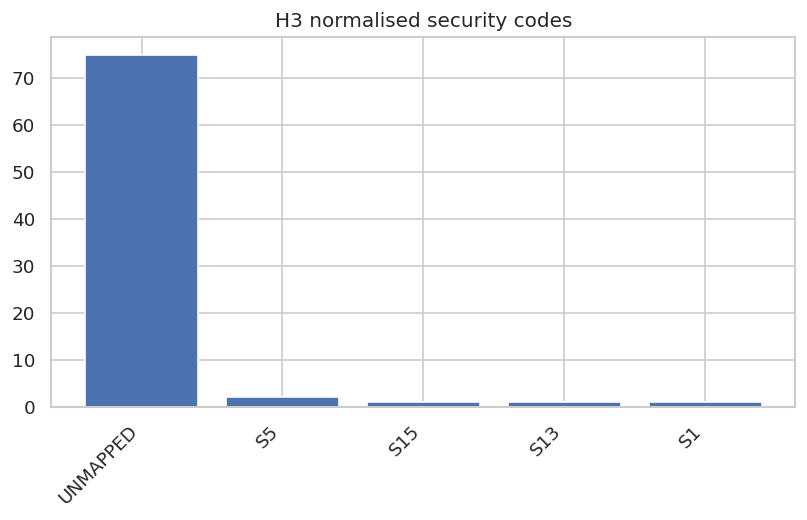

H3 audit review complete.


In [5]:
review_ids = rd.select_review_topics(
    h3,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    force_ids=app["topic_id"].tolist(),
    per_code=3,
    seed=42,
)
packs = rd.show_review_set(
    cfg,
    h3,
    review_ids,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    code_col=CODE_COL,
)
ctx.save_markdown(
    rd.render_review_markdown(packs, title="H3 security / material — close-reading pack"),
    "close_reading_pack",
)
ctx.save_table(
    h3[
        [
            "topic_id",
            "current_topic_label",
            "current_taxonomy_id",
            "current_taxonomy_name",
            "security_code",
            "code_norm",
            "mixed_topic",
        ]
    ],
    "security_topic_annotations",
)

fig, ax = plt.subplots(figsize=(8, 4))
vc = h3["code_norm"].fillna("UNMAPPED").value_counts()
ax.bar(vc.index.astype(str), vc.values)
ax.set_title("H3 normalised security codes")
plt.xticks(rotation=45, ha="right")
ctx.save_figure(fig, "h3_code_distribution")
plt.show()

print("H3 audit review complete.")